# Restaurant Cuisine Classification using Machine Learning

## Project Overview

This project builds a machine learning classification model to predict a restaurant's primary cuisine based on restaurant characteristics such as ratings, votes, price range, and city.

The model can be used to automatically classify restaurants into cuisine categories, helping food delivery platforms improve restaurant organization and search.

## Objectives

- Build a restaurant cuisine classification model.
- Predict the primary cuisine of a restaurant.
- Compare restaurant features for classification.
- Evaluate model performance using classification metrics.

## Workflow

1. Import Libraries
2. Load Dataset
3. Data Preparation
4. Feature Engineering
5. Encode Features
6. Train-Test Split
7. Model Training
8. Model Evaluation
9. Confusion Matrix
10. Conclusion






## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

## Load Dataset

In [5]:
df = pd.read_csv("C:/Users/Triveni/OneDrive/Documents/Restaurant-Analytics-ML/data/restaurant.csv")

      




## Data Preparation

In [7]:
df.head()



,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [9]:

df.isnull().sum()





Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [10]:
df = df.dropna(
    subset=[
        "Cuisines",
        "Aggregate rating",
        "Votes",
        "Price range",
        "City"
    ]
)

df.isnull().sum()




Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


## Feature Engineering

In [12]:
# Extract the primary cuisine from the cuisine list

df["Primary Cuisine"] = df["Cuisines"].str.split(",").str[0]

df[["Cuisines", "Primary Cuisine"]].head()


,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese


## Select Top Cuisine Categories





In [14]:
# Select the 20 most common cuisines

top_20_cuisines = (
    df["Primary Cuisine"]
    .value_counts()
    .head(20)
    .index
)

top_20_cuisines





Index(['North Indian', 'Chinese', 'Fast Food', 'Bakery', 'Cafe', 'American',
       'South Indian', 'Mithai', 'Street Food', 'Continental', 'Italian',
       'Pizza', 'Mughlai', 'Ice Cream', 'Desserts', 'Burger', 'Biryani',
       'Raw Meats', 'Beverages', 'Finger Food'],
      dtype='object', name='Primary Cuisine')

In [15]:

# Keep only restaurants belonging to the top 20 cuisines

classification_df = df[
    df["Primary Cuisine"].isin(top_20_cuisines)
].copy()

classification_df.head()



,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,No,No,No,No,3,4.4,Green,Very Good,336,Chinese
11,6309455,Mad Mark's Creamery & Good Eats,162,Pasig City,"23 East Capitol Drive, Kapitolyo, Pasig City",Kapitolyo,"Kapitolyo, Pasig City",121.060820,14.570849,"American, Ice Cream, Desserts",...,Yes,No,No,No,3,4.2,Green,Very Good,488,American
15,18185059,Cafe Arabelle,162,Santa Rosa,"Ayala Mall, Solenad, Nuvali, Santa Rosa - Taga...","Nuvali, Don Jose, Santa Rosa","Nuvali, Don Jose, Santa Rosa, Santa Rosa",121.057040,14.237082,"Cafe, American, Italian, Filipino",...,No,No,No,No,3,3.6,Yellow,Good,29,Cafe
16,18182702,Nonna's Pasta & Pizzeria,162,Santa Rosa,"Ground Floor, Building G, Solenad 3, Nuvali, D...","Solenad 3, Don Jose, Santa Rosa","Solenad 3, Don Jose, Santa Rosa, Santa Rosa",121.056587,14.237679,"Italian, Pizza",...,No,No,No,No,3,4.0,Green,Very Good,72,Italian
18,18255654,Hobing Korean Dessert Cafe,162,Taguig City,"Third Floor, BGC Stopover Pavillion, Rizal Dri...","BGC Stopover Pavillion, Bonifacio Global City","BGC Stopover Pavillion, Bonifacio Global City,...",121.045878,14.554360,"Cafe, Korean, Desserts",...,No,No,No,No,2,4.5,Dark Green,Excellent,118,Cafe



## Encode Features

In [17]:
# Encode categorical columns

cuisine_encoder = LabelEncoder()
city_encoder = LabelEncoder()

classification_df["Cuisine Encoded"] = (
    cuisine_encoder.fit_transform(
        classification_df["Primary Cuisine"]
    )
)

classification_df["City Encoded"] = (
    city_encoder.fit_transform(
        classification_df["City"]
    )
)

classification_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine,Cuisine Encoded,City Encoded
5,18189371,Din Tai Fung,162,Mandaluyong City,"Ground Floor, Mega Fashion Hall, SM Megamall, ...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056314,14.583764,Chinese,...,No,No,3,4.4,Green,Very Good,336,Chinese,6,62
11,6309455,Mad Mark's Creamery & Good Eats,162,Pasig City,"23 East Capitol Drive, Kapitolyo, Pasig City",Kapitolyo,"Kapitolyo, Pasig City",121.060820,14.570849,"American, Ice Cream, Desserts",...,No,No,3,4.2,Green,Very Good,488,American,0,75
15,18185059,Cafe Arabelle,162,Santa Rosa,"Ayala Mall, Solenad, Nuvali, Santa Rosa - Taga...","Nuvali, Don Jose, Santa Rosa","Nuvali, Don Jose, Santa Rosa, Santa Rosa",121.057040,14.237082,"Cafe, American, Italian, Filipino",...,No,No,3,3.6,Yellow,Good,29,Cafe,5,89
16,18182702,Nonna's Pasta & Pizzeria,162,Santa Rosa,"Ground Floor, Building G, Solenad 3, Nuvali, D...","Solenad 3, Don Jose, Santa Rosa","Solenad 3, Don Jose, Santa Rosa, Santa Rosa",121.056587,14.237679,"Italian, Pizza",...,No,No,3,4.0,Green,Very Good,72,Italian,12,89
18,18255654,Hobing Korean Dessert Cafe,162,Taguig City,"Third Floor, BGC Stopover Pavillion, Rizal Dri...","BGC Stopover Pavillion, Bonifacio Global City","BGC Stopover Pavillion, Bonifacio Global City,...",121.045878,14.554360,"Cafe, Korean, Desserts",...,No,No,2,4.5,Dark Green,Excellent,118,Cafe,5,97


In [18]:
# Select input features and target
feature_columns = [
    "Aggregate rating",
    "Votes",
    "Price range",
    "City Encoded",
    "Average Cost for two",
    "Longitude",
    "Latitude"
]

X = classification_df[feature_columns]

y = classification_df["Cuisine Encoded"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)



Feature Shape: (8518, 7)
Target Shape: (8518,)


## Split the Dataset

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (6814, 7)
Testing Set: (1704, 7)


## Model Training

In [22]:
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [23]:
y_pred = rf_classifier.predict(X_test)

## Model Evaluation

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 34.86%


In [26]:
report = classification_report(
    y_test,
    y_pred,
    target_names=cuisine_encoder.classes_,
    output_dict=True
)

report_df = (
    pd.DataFrame(report)
    .transpose()
    .round(2)
)

report_df

,precision,recall,f1-score,support
American,0.38,0.36,0.37,56.00
Bakery,0.16,0.15,0.16,124.00
Beverages,0.00,0.00,0.00,16.00
Biryani,0.00,0.00,0.00,22.00
Burger,0.07,0.04,0.05,23.00
Cafe,0.39,0.31,0.34,123.00
Chinese,0.19,0.12,0.15,171.00
Continental,0.16,0.06,0.09,47.00
Desserts,0.06,0.03,0.04,30.00
Fast Food,0.21,0.13,0.16,135.00


## Confusion Matrix

<Figure size 1200x1000 with 0 Axes>

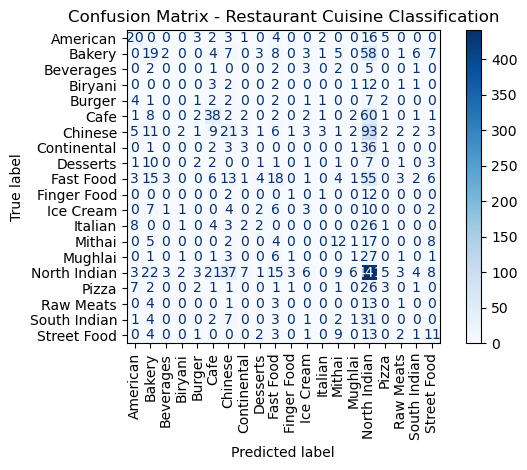

In [28]:
plt.figure(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=cuisine_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Confusion Matrix - Restaurant Cuisine Classification")

plt.tight_layout()

plt.show()

# Conclusion

## Summary

This project developed a multiclass machine learning model to classify the primary cuisine of restaurants using features such as ratings, votes, price range, location, and average cost.

### Key Findings

- Successfully prepared and processed restaurant data for multiclass classification.
- Applied Label Encoding to categorical features.
- Trained a Random Forest classifier to predict the primary cuisine.
- Evaluated the model using accuracy, a classification report, and a confusion matrix.

### Real-World Applications

- Automatic restaurant categorization
- Food delivery platforms
- Restaurant search and discovery
- Restaurant database management

### Limitations

The model achieved moderate accuracy because multiple cuisines often have similar ratings, pricing, and customer engagement patterns, making cuisine prediction a challenging multiclass classification problem.

### Future Improvements

- Add more descriptive restaurant features.
- Experiment with XGBoost and LightGBM.
- Apply hyperparameter tuning.
- Deploy the model as a web application using Streamlit.